# Treinamento com interface de alto nível

## Importação das bibliotecas

In [ ]:
# http://pytorch.org/
from os.path import exists

import torch

In [ ]:
import argparse
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.optim.lr_scheduler import StepLR
import pandas as pd
from torch.utils.data import Dataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
use_cuda = torch.cuda.is_available()
torch.manual_seed(1111)
device = torch.device("cuda" if use_cuda else "cpu")

##Preparação dos Dados




In [ ]:
#!/bin/bash
!curl -L -o /content/housesalesprediction.zip\
  https://www.kaggle.com/api/v1/datasets/download/harlfoxem/housesalesprediction

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  779k  100  779k    0     0   360k      0  0:00:02  0:00:02 --:--:--  686k


In [ ]:
!unzip /content/housesalesprediction.zip

Archive:  /content/housesalesprediction.zip
  inflating: kc_house_data.csv       


In [ ]:
df = pd.read_csv("/content/kc_house_data.csv")

In [ ]:
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

In [ ]:
for col in df.columns:
  if df[col].dtype == 'object':
    df[col] = LabelEncoder().fit_transform(df[col])

In [ ]:
features = ['bedrooms','bathrooms','sqft_living','sqft_lot','floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long']
target = 'price'

X = df[features].values
Y = df[target].values

In [ ]:
X.shape

(21613, 16)

In [ ]:
class HousePredctionDataset(Dataset):
    def __init__(self, x, y):
        self.x = x
        self.y = y

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

In [ ]:

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

X_scaler = StandardScaler()
X_train = X_scaler.fit_transform(X_train)
X_test = X_scaler.transform(X_test)

y_scaler = MinMaxScaler()
y_train = y_scaler.fit_transform(y_train.reshape(-1, 1))
y_test = y_scaler.transform(y_test.reshape(-1, 1))

In [ ]:
y_train

array([[0.09601311],
       [0.06491803],
       [0.03213115],
       ...,
       [0.06557377],
       [0.02229508],
       [0.03147541]])

In [ ]:
train_dataset = HousePredctionDataset(torch.FloatTensor(X_train), torch.FloatTensor(y_train))
test_dataset = HousePredctionDataset(torch.FloatTensor(X_test), torch.FloatTensor(y_test))

In [ ]:
train_dataset[5]

(tensor([-1.4625, -1.4515, -1.5286, -0.1611, -0.9213, -0.0844, -0.3048,  0.9096,
         -2.2609, -1.3373, -0.6549, -0.6878, -0.2076,  2.0617, -0.7556, -0.5343]),
 tensor([0.0155]))

In [ ]:
train_kwargs = {'batch_size': 100}
test_kwargs = {'batch_size': 100}
if use_cuda:
    cuda_kwargs = {'num_workers': 1,
                    'pin_memory': True,
                    'shuffle': True}
    train_kwargs.update(cuda_kwargs)
    test_kwargs.update(cuda_kwargs)

train_loader = torch.utils.data.DataLoader(train_dataset,**train_kwargs)
test_loader = torch.utils.data.DataLoader(test_dataset, **test_kwargs)

## Criação da rede

In [ ]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.input = nn.Linear(X_train.shape[1], 128)
        self.drop1 = nn.Dropout(0.3)
        self.hidden = nn.Linear(128, 256)
        self.drop2 = nn.Dropout(0.3)
        self.fc2 = nn.Linear(256, 1)

    def forward(self, x):
        x = self.input(x)
        x = F.relu(x)
        x = self.drop1(x)
        x = self.hidden(x)
        x = F.relu(x)
        x = self.drop2(x)
        x = self.fc2(x)
        return x

model = Net()

In [ ]:
model

Net(
  (input): Linear(in_features=16, out_features=128, bias=True)
  (drop1): Dropout(p=0.3, inplace=False)
  (hidden): Linear(in_features=128, out_features=256, bias=True)
  (drop2): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=256, out_features=1, bias=True)
)

## Treinamento

### Criando o objeto de treinamento

In [ ]:
def train(model, device, train_loader, optimizer, criterion):
    model.train()
    running_loss = 0.0
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * data.size(0)
    train_loss = running_loss / len(train_loader.dataset)
    return train_loss

In [ ]:
def test(model, device, test_loader, criterion):
    model.eval()
    test_loss = 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss += criterion(output, target).item() * data.size(0)
    test_loss /= len(test_loader.dataset)

    return test_loss

## Avaliação

In [ ]:
epochs = 100
lr = 0.001
lr_decay = 10
patience = 10
patience_counter = 0
best_loss = float('inf')

history = {'train_loss': [], 'test_loss': []}

model = Net().to(device)
optimizer = optim.Adam(model.parameters(), lr=lr)
criterion = nn.MSELoss()
scheduler = StepLR(optimizer, step_size=lr_decay, gamma=0.5)

print("Iniciando Treinamento ...")

for epoch in range(1, epochs + 1):

  train_loss = train(model, device, train_loader, optimizer, criterion)
  test_loss = test(model, device, test_loader, criterion)
  scheduler.step()

  print(f"Época: {epoch} | Train Loss: {train_loss:.4f}| Test Loss: {test_loss:.4f}")

  history['train_loss'].append(train_loss)
  history['test_loss'].append(test_loss)

  if test_loss < best_loss:
    best_loss = test_loss
    print("Salvando melhor época ...")
    torch.save(model.state_dict(), "mnist_cnn.pt")
    patience_counter = 0
  else:
    patience_counter += 1
    if patience_counter == patience:
      print(f"Parando Treinamento por Patience na época {epoch}...")
      break

Iniciando Treinamento ...
Época: 1 | Train Loss: 0.0036| Test Loss: 0.0009
Salvando melhor época ...
Época: 2 | Train Loss: 0.0010| Test Loss: 0.0008
Salvando melhor época ...
Época: 3 | Train Loss: 0.0008| Test Loss: 0.0007
Salvando melhor época ...
Época: 4 | Train Loss: 0.0007| Test Loss: 0.0008
Época: 5 | Train Loss: 0.0006| Test Loss: 0.0007
Salvando melhor época ...
Época: 6 | Train Loss: 0.0006| Test Loss: 0.0008
Época: 7 | Train Loss: 0.0006| Test Loss: 0.0006
Salvando melhor época ...
Época: 8 | Train Loss: 0.0005| Test Loss: 0.0005
Salvando melhor época ...
Época: 9 | Train Loss: 0.0005| Test Loss: 0.0007
Época: 10 | Train Loss: 0.0005| Test Loss: 0.0006
Época: 11 | Train Loss: 0.0005| Test Loss: 0.0006
Época: 12 | Train Loss: 0.0004| Test Loss: 0.0005
Época: 13 | Train Loss: 0.0004| Test Loss: 0.0005
Salvando melhor época ...
Época: 14 | Train Loss: 0.0005| Test Loss: 0.0005
Época: 15 | Train Loss: 0.0004| Test Loss: 0.0005
Época: 16 | Train Loss: 0.0004| Test Loss: 0.0005
É

## Visualização dos Resultados

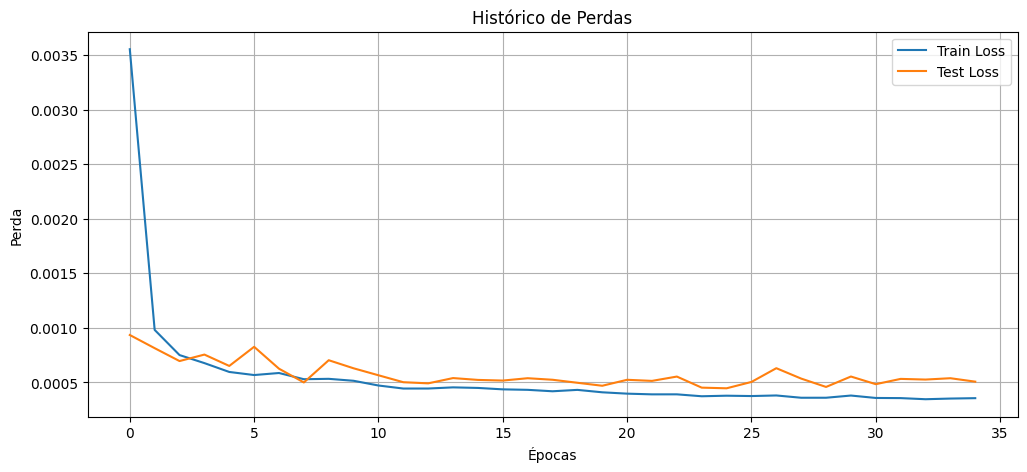

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 5))

#Perda
plt.subplot(1, 1, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['test_loss'], label='Test Loss')
plt.title('Histórico de Perdas')
plt.xlabel('Épocas')
plt.ylabel('Perda')
plt.legend()
plt.grid(True)

plt.show()